In [1]:
#Test file for main.py
from dotenv import load_dotenv

load_dotenv()

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
# 상대 경로(.)를 모두 제거하고 패키지명(graph)을 명시했습니다.
from graph.state import GraphState
from graph.nodes.triage_router import triage_router
from graph.nodes.policy_scope_guard import policy_scope_guard
from graph.nodes.policy_completeness_guard import policy_completeness_guard
from graph.nodes.policy_risk_guard import policy_risk_guard
from graph.nodes.order_agent import order_agent
from graph.nodes.billing_agent import billing_agent


def route_to_agent(state: GraphState) -> str:
    if state.get("policy_status") in {"OUT_OF_SCOPE", "NEED_MORE_INFO"}:
        return "end"

    category = state.get("category")

    if category == "order":
        return "order_agent"
    if category == "billing":
        return "billing_agent"

    return "end"


graph = StateGraph(GraphState)

# 노드 등록
graph.add_node("triage", triage_router)
graph.add_node("policy_scope", policy_scope_guard)
graph.add_node("policy_completeness", policy_completeness_guard)
graph.add_node("policy_risk", policy_risk_guard)
graph.add_node("order_agent", order_agent)
graph.add_node("billing_agent", billing_agent)

# 진입점 설정 (사용자님이 선택하신 보장된 계약 방식)

graph.add_edge(START, "triage")
graph.add_edge("triage", "policy_scope")
graph.add_edge("policy_scope", "policy_completeness")
graph.add_edge("policy_completeness", "policy_risk")

# 조건부 엣지 연결
graph.add_conditional_edges(
    "policy_risk",
    route_to_agent,
    {
        "order_agent": "order_agent",
        "billing_agent": "billing_agent",
        "end": END,
    }
)

# 에이전트 작업 완료 후 종료
graph.add_edge("order_agent", END)
graph.add_edge("billing_agent", END)

# 최종 컴파일 — 체크포인터 있어야 같은 thread_id로 대화가 이어짐
graphs = graph.compile(checkpointer=MemorySaver())


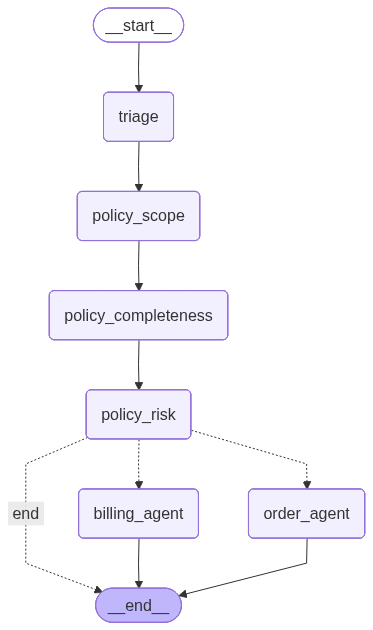

In [2]:
graphs